# 03 — Evaluation & Results

Loads trained models, runs them on the test period (Dec 2025), and computes:
- Cumulative return
- Sharpe ratio
- Maximum drawdown
- Turnover (number of trades)

Compared against:
- **Buy-and-hold** (single ticker)
- **Equal-weight buy-and-hold** (all 3 tickers)
- **Momentum baseline** (buy if last 5-day return > 0, else hold)

In [12]:
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from trading_env import TradingEnv, make_envs
from stable_baselines3 import PPO, DQN

DATA_DIR    = PROJECT_ROOT / 'llm/data'
MODELS_DIR  = PROJECT_ROOT / 'llm/models'
RESULTS_DIR = PROJECT_ROOT / 'llm/results'
RESULTS_DIR.mkdir(exist_ok=True)

TICKERS      = ['NVDA', 'GOOG', 'TSLA']
TRAIN_CUTOFF = '2025-11-30'
INITIAL_CASH = 10_000.0

daily = pd.read_csv(DATA_DIR / 'daily_features.csv', parse_dates=['date'])
print('Dataset loaded:', daily.shape)

Dataset loaded: (192, 33)


## 1. Metrics Helper Functions

In [13]:
def sharpe_ratio(returns, risk_free=0.0, periods_per_year=252):
    """Annualized Sharpe ratio from a series of period returns."""
    excess = returns - risk_free / periods_per_year
    if excess.std() < 1e-8:
        return 0.0
    return float(excess.mean() / excess.std() * np.sqrt(periods_per_year))

def max_drawdown(portfolio_values):
    """Maximum peak-to-trough drawdown."""
    vals = np.array(portfolio_values)
    peak = np.maximum.accumulate(vals)
    drawdown = (vals - peak) / peak
    return float(drawdown.min())

def cumulative_return(portfolio_values):
    return float((portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0])

def compute_metrics(history_df):
    pv = history_df['portfolio_value'].values
    daily_returns = np.diff(pv) / pv[:-1]
    trades = (history_df['action'] != 1).sum()  # non-hold actions
    return {
        'cumulative_return': cumulative_return(pv),
        'sharpe_ratio':      sharpe_ratio(pd.Series(daily_returns)),
        'max_drawdown':      max_drawdown(pv),
        'turnover':          int(trades),
        'final_value':       float(pv[-1]),
    }

print('Metrics helpers ready.')

Metrics helpers ready.


## 2. Evaluate RL Agents

In [14]:
def run_agent(model, env):
    obs, _ = env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(action)
    return env.get_history()

ALGO_CLASSES = {'PPO': PPO, 'DQN': DQN}
STATE_TYPES = ['price', 'sentiment_basic', 'sentiment_enhanced']
ENV_KWARGS = dict(
    reward_mode='log_return',
    drawdown_penalty=0.0,
    volatility_penalty=0.0,
)

all_results = []
histories   = {}  # (ticker, algo, state_type) -> history_df

for ticker in TICKERS:
    envs = make_envs(daily, ticker, TRAIN_CUTOFF, env_kwargs=ENV_KWARGS)

    for algo_name in ['PPO', 'DQN']:
        for state_type in STATE_TYPES:
            model_path = MODELS_DIR / f'{ticker}_{algo_name}_{state_type}.zip'
            if not model_path.exists():
                print(f'  MISSING: {model_path.name} — run notebook 02 first')
                continue

            AlgoClass = ALGO_CLASSES[algo_name]
            model = AlgoClass.load(str(model_path))

            test_env = envs[f'test_{state_type}']
            history = run_agent(model, test_env)
            metrics = compute_metrics(history)

            key = (ticker, algo_name, state_type)
            histories[key] = history
            all_results.append({
                'ticker': ticker, 'algo': algo_name, 'state': state_type, **metrics
            })

results_df = pd.DataFrame(all_results)
print('RL evaluation done.')
results_df


RL evaluation done.


,ticker,algo,state,cumulative_return,sharpe_ratio,max_drawdown,turnover,final_value
0,NVDA,PPO,price,-0.027637,-3.671816,-0.036061,16,9759.337281
1,NVDA,PPO,sentiment_basic,-0.016533,-3.373368,-0.017344,19,9870.789081
2,NVDA,PPO,sentiment_enhanced,0.027349,4.352579,-0.003713,12,10273.487525
3,NVDA,DQN,price,0.023977,2.924650,-0.016777,14,10239.767915
4,NVDA,DQN,sentiment_basic,0.032620,3.665521,-0.017344,13,10364.118553
5,NVDA,DQN,sentiment_enhanced,0.024683,2.170260,-0.039260,8,10246.825082
6,GOOG,PPO,price,0.009216,1.370707,-0.025785,18,10101.014559
7,GOOG,PPO,sentiment_basic,0.009232,1.373013,-0.025785,18,10101.174067
8,GOOG,PPO,sentiment_enhanced,0.001686,0.292072,-0.025961,20,10025.648071
9,GOOG,DQN,price,-0.024273,-3.253950,-0.034526,14,9757.266911


In [15]:
delta_rows = []
for ticker in TICKERS:
    sub = results_df[results_df['ticker'] == ticker]
    for algo in ['PPO', 'DQN']:
        price = sub[(sub['algo'] == algo) & (sub['state'] == 'price')]
        basic = sub[(sub['algo'] == algo) & (sub['state'] == 'sentiment_basic')]
        enhanced = sub[(sub['algo'] == algo) & (sub['state'] == 'sentiment_enhanced')]
        if len(price) == 0 or len(basic) == 0 or len(enhanced) == 0:
            continue

        price = price.iloc[0]
        basic = basic.iloc[0]
        enhanced = enhanced.iloc[0]

        delta_rows.append({
            'ticker': ticker,
            'algo': algo,
            'enhanced_vs_basic_return_pp': (enhanced['cumulative_return'] - basic['cumulative_return']) * 100,
            'enhanced_vs_basic_sharpe': enhanced['sharpe_ratio'] - basic['sharpe_ratio'],
            'enhanced_vs_price_return_pp': (enhanced['cumulative_return'] - price['cumulative_return']) * 100,
            'enhanced_vs_price_sharpe': enhanced['sharpe_ratio'] - price['sharpe_ratio'],
        })

delta_df = pd.DataFrame(delta_rows).round(3)
print('=== Enhanced Sentiment Delta Table ===')
print(delta_df.to_string(index=False))
delta_df.to_csv(RESULTS_DIR / 'enhanced_delta_table.csv', index=False)
print('\nSaved results/enhanced_delta_table.csv')


=== Enhanced Sentiment Delta Table ===
ticker algo  enhanced_vs_basic_return_pp  enhanced_vs_basic_sharpe  enhanced_vs_price_return_pp  enhanced_vs_price_sharpe
  NVDA  PPO                        4.388                     7.726                        5.499                     8.024
  NVDA  DQN                       -0.794                    -1.495                        0.071                    -0.754
  GOOG  PPO                       -0.755                    -1.081                       -0.753                    -1.079
  GOOG  DQN                        0.401                     0.469                        2.499                     3.390
  TSLA  PPO                       -1.167                    -2.020                       -5.087                    -3.836
  TSLA  DQN                        2.091                     1.490                        4.004                     0.536

Saved results/enhanced_delta_table.csv


## 3. Compute Baselines

In [16]:
baseline_results = []
baseline_histories = {}

def buy_and_hold(test_df, initial_cash=INITIAL_CASH):
    """Buy as many shares as possible on day 0, hold until end."""
    prices = test_df['close'].values
    shares = int(initial_cash // prices[0])
    cash = initial_cash - shares * prices[0]
    portfolio = cash + shares * prices
    daily_ret = np.diff(portfolio) / portfolio[:-1]
    actions = np.ones(len(prices), dtype=int)  # all hold
    actions[0] = 2  # buy
    return pd.DataFrame({
        'portfolio_value': portfolio,
        'action': actions,
    }), portfolio

def momentum_baseline(test_df, initial_cash=INITIAL_CASH, window=5):
    """Buy when 5-day return is positive, sell otherwise."""
    prices = test_df['close'].values
    cash = initial_cash
    position = 0
    portfolio = []
    actions = []
    for i in range(len(prices)):
        pv = cash + position * prices[i]
        portfolio.append(pv)
        if i >= window:
            momentum = prices[i] / prices[i - window] - 1
            if momentum > 0 and position == 0 and cash >= prices[i]:
                position += 1
                cash -= prices[i]
                actions.append(2)
            elif momentum <= 0 and position > 0:
                cash += position * prices[i]
                position = 0
                actions.append(0)
            else:
                actions.append(1)
        else:
            actions.append(1)
    return pd.DataFrame({'portfolio_value': portfolio, 'action': actions}), np.array(portfolio)

for ticker in TICKERS:
    test_df = daily[(daily['ticker'] == ticker) & (daily['date'] > TRAIN_CUTOFF)].copy()
    if len(test_df) == 0:
        continue

    for baseline_name, fn in [('buy_and_hold', buy_and_hold), ('momentum', momentum_baseline)]:
        hist, pv = fn(test_df)
        metrics = compute_metrics(hist)
        baseline_histories[(ticker, baseline_name)] = hist
        baseline_results.append({
            'ticker': ticker, 'algo': baseline_name, 'state': 'baseline', **metrics
        })

# Equal-weight buy-and-hold across all 3 tickers
eq_cash = INITIAL_CASH / 3
eq_portfolios = []
for ticker in TICKERS:
    test_df = daily[(daily['ticker'] == ticker) & (daily['date'] > TRAIN_CUTOFF)].copy()
    _, pv = buy_and_hold(test_df, initial_cash=eq_cash)
    # Align lengths
    eq_portfolios.append(pv)

min_len = min(len(p) for p in eq_portfolios)
eq_total = sum(p[:min_len] for p in eq_portfolios)
eq_actions = np.ones(min_len, dtype=int)
eq_actions[0] = 2
eq_hist = pd.DataFrame({'portfolio_value': eq_total, 'action': eq_actions})
eq_metrics = compute_metrics(eq_hist)
baseline_results.append({'ticker': 'ALL', 'algo': 'equal_weight_bh', 'state': 'baseline', **eq_metrics})

baselines_df = pd.DataFrame(baseline_results)
print('Baselines computed.')
baselines_df

Baselines computed.


,ticker,algo,state,cumulative_return,sharpe_ratio,max_drawdown,turnover,final_value
0,NVDA,buy_and_hold,baseline,0.036190,1.580470,-0.077942,1,10361.900101
1,NVDA,momentum,baseline,0.000089,0.394521,-0.000462,4,10000.889984
2,GOOG,buy_and_hold,baseline,-0.004092,-0.130587,-0.072917,1,9959.079773
3,GOOG,momentum,baseline,-0.000158,-0.581091,-0.000730,4,9998.420013
4,TSLA,buy_and_hold,baseline,0.045034,1.569225,-0.081210,1,10450.339691
5,TSLA,momentum,baseline,0.002370,2.084134,-0.002253,6,10023.700043
6,ALL,equal_weight_bh,baseline,0.024230,1.435060,-0.036593,1,10242.299866


## 4. Results Table

In [17]:
combined = pd.concat([results_df, baselines_df], ignore_index=True)

fmt = combined.copy()
fmt['cumulative_return'] = (fmt['cumulative_return'] * 100).round(2).astype(str) + '%'
fmt['sharpe_ratio']      = fmt['sharpe_ratio'].round(3)
fmt['max_drawdown']      = (fmt['max_drawdown'] * 100).round(2).astype(str) + '%'
fmt['final_value']       = '$' + fmt['final_value'].round(2).astype(str)

display_cols = ['ticker', 'algo', 'state', 'cumulative_return', 'sharpe_ratio', 'max_drawdown', 'turnover', 'final_value']
print('\n=== FULL RESULTS TABLE ===')
print(fmt[display_cols].to_string(index=False))

combined.to_csv(RESULTS_DIR / 'results.csv', index=False)
print('\nSaved to results/results.csv')


=== FULL RESULTS TABLE ===
ticker            algo              state cumulative_return  sharpe_ratio max_drawdown  turnover final_value
  NVDA             PPO              price            -2.76%        -3.672       -3.61%        16    $9759.34
  NVDA             PPO    sentiment_basic            -1.65%        -3.373       -1.73%        19    $9870.79
  NVDA             PPO sentiment_enhanced             2.73%         4.353       -0.37%        12   $10273.49
  NVDA             DQN              price              2.4%         2.925       -1.68%        14   $10239.77
  NVDA             DQN    sentiment_basic             3.26%         3.666       -1.73%        13   $10364.12
  NVDA             DQN sentiment_enhanced             2.47%         2.170       -3.93%         8   $10246.83
  GOOG             PPO              price             0.92%         1.371       -2.58%        18   $10101.01
  GOOG             PPO    sentiment_basic             0.92%         1.373       -2.58%        18   $

## 5. Price vs Sentiment Comparison

In [18]:
print('=== Feature Ablation: Price vs Basic vs Enhanced Sentiment ===')
print()

comparisons = [
    ('sentiment_basic', 'price'),
    ('sentiment_enhanced', 'price'),
    ('sentiment_enhanced', 'sentiment_basic'),
]

for ticker in TICKERS:
    print(f'--- {ticker} ---')
    sub = results_df[results_df['ticker'] == ticker]
    for algo in ['PPO', 'DQN']:
        for left, right in comparisons:
            left_row = sub[(sub['algo'] == algo) & (sub['state'] == left)]
            right_row = sub[(sub['algo'] == algo) & (sub['state'] == right)]
            if len(left_row) == 0 or len(right_row) == 0:
                continue
            left_row, right_row = left_row.iloc[0], right_row.iloc[0]
            ret_delta = left_row['cumulative_return'] - right_row['cumulative_return']
            sharpe_delta = left_row['sharpe_ratio'] - right_row['sharpe_ratio']
            print(f'  {algo} | {left} vs {right}: return {ret_delta*100:+.2f}pp | sharpe {sharpe_delta:+.3f}')
    print()


=== Feature Ablation: Price vs Basic vs Enhanced Sentiment ===

--- NVDA ---
  PPO | sentiment_basic vs price: return +1.11pp | sharpe +0.298
  PPO | sentiment_enhanced vs price: return +5.50pp | sharpe +8.024
  PPO | sentiment_enhanced vs sentiment_basic: return +4.39pp | sharpe +7.726
  DQN | sentiment_basic vs price: return +0.86pp | sharpe +0.741
  DQN | sentiment_enhanced vs price: return +0.07pp | sharpe -0.754
  DQN | sentiment_enhanced vs sentiment_basic: return -0.79pp | sharpe -1.495

--- GOOG ---
  PPO | sentiment_basic vs price: return +0.00pp | sharpe +0.002
  PPO | sentiment_enhanced vs price: return -0.75pp | sharpe -1.079
  PPO | sentiment_enhanced vs sentiment_basic: return -0.75pp | sharpe -1.081
  DQN | sentiment_basic vs price: return +2.10pp | sharpe +2.921
  DQN | sentiment_enhanced vs price: return +2.50pp | sharpe +3.390
  DQN | sentiment_enhanced vs sentiment_basic: return +0.40pp | sharpe +0.469

--- TSLA ---
  PPO | sentiment_basic vs price: return -3.92pp | 

## 6. Portfolio Value Over Time

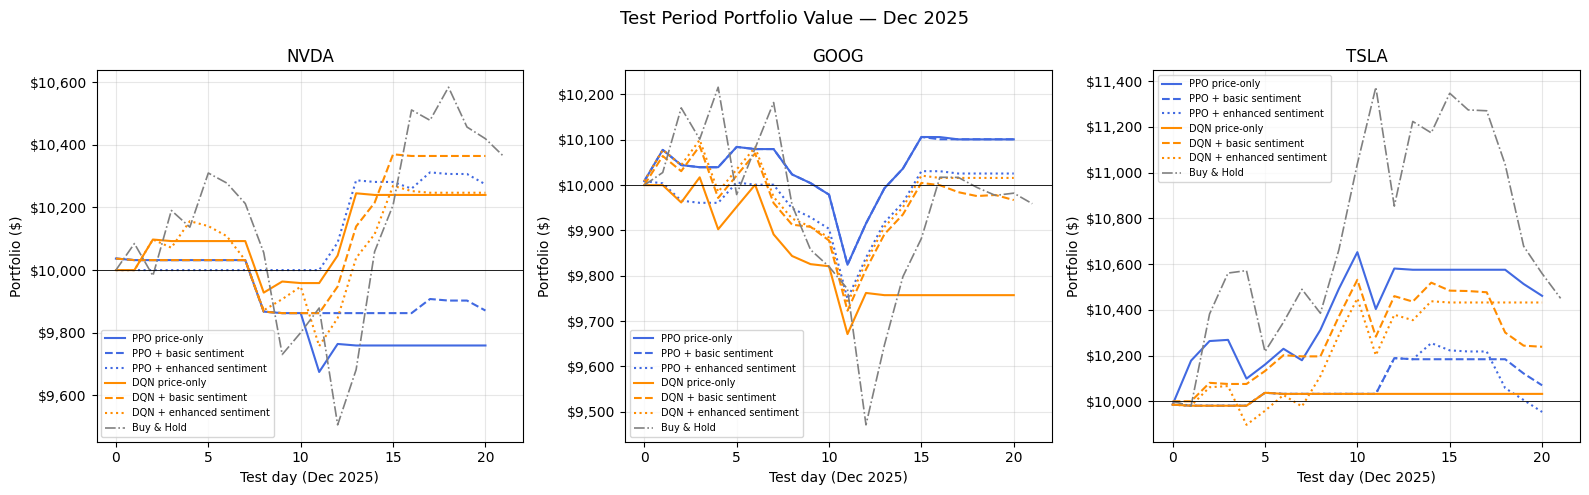

Saved results/portfolio_curves.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle('Test Period Portfolio Value — Dec 2025', fontsize=13)

styles = {
    ('PPO', 'price'):              ('royalblue',  '-',  'PPO price-only'),
    ('PPO', 'sentiment_basic'):    ('royalblue',  '--', 'PPO + basic sentiment'),
    ('PPO', 'sentiment_enhanced'): ('royalblue',  ':',  'PPO + enhanced sentiment'),
    ('DQN', 'price'):              ('darkorange', '-',  'DQN price-only'),
    ('DQN', 'sentiment_basic'):    ('darkorange', '--', 'DQN + basic sentiment'),
    ('DQN', 'sentiment_enhanced'): ('darkorange', ':',  'DQN + enhanced sentiment'),
}

for ax, ticker in zip(axes, TICKERS):
    for (algo, state), (color, ls, label) in styles.items():
        key = (ticker, algo, state)
        if key in histories:
            ax.plot(histories[key]['portfolio_value'].values, color=color, linestyle=ls, label=label, linewidth=1.5)

    bh_key = (ticker, 'buy_and_hold')
    if bh_key in baseline_histories:
        ax.plot(baseline_histories[bh_key]['portfolio_value'].values,
                color='gray', linestyle='-.', linewidth=1.2, label='Buy & Hold')

    ax.axhline(INITIAL_CASH, color='black', linewidth=0.6)
    ax.set_title(ticker)
    ax.set_xlabel('Test day (Dec 2025)')
    ax.set_ylabel('Portfolio ($)')
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'portfolio_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/portfolio_curves.png')


## 7. Sharpe Ratio Comparison Chart

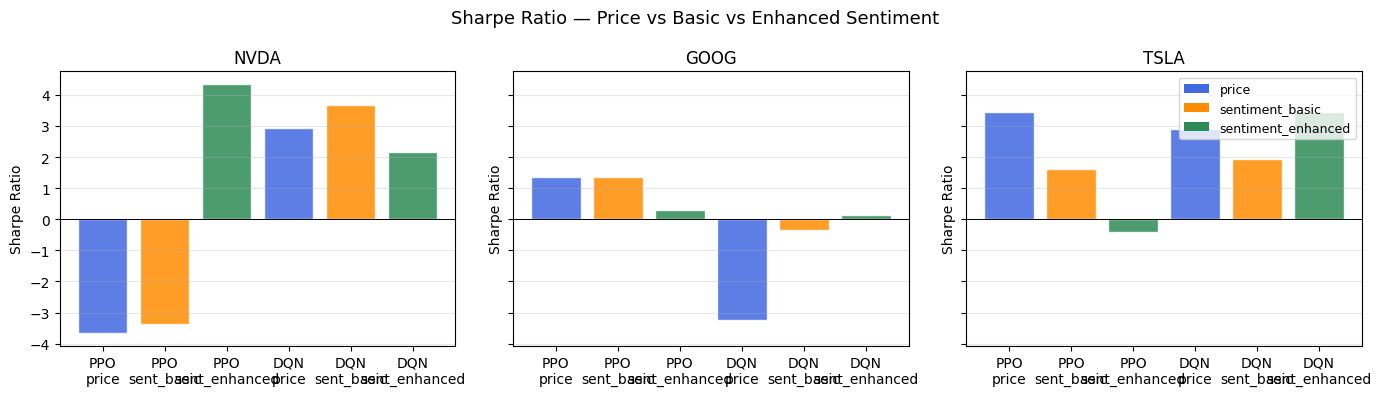

Saved results/sharpe_comparison.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle('Sharpe Ratio — Price vs Basic vs Enhanced Sentiment', fontsize=13)

state_palette = {
    'price': 'royalblue',
    'sentiment_basic': 'darkorange',
    'sentiment_enhanced': 'seagreen',
}

for ax, ticker in zip(axes, TICKERS):
    sub = results_df[results_df['ticker'] == ticker]
    labels, bars, bar_colors = [], [], []
    for algo in ['PPO', 'DQN']:
        for state in STATE_TYPES:
            row = sub[(sub['algo'] == algo) & (sub['state'] == state)]
            if len(row) == 0:
                continue
            labels.append(f'{algo}\n{state.replace("sentiment_", "sent_")}')
            bars.append(row.iloc[0]['sharpe_ratio'])
            bar_colors.append(state_palette[state])

    ax.bar(labels, bars, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title(ticker)
    ax.set_ylabel('Sharpe Ratio')
    ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=state_palette[state], label=state) for state in STATE_TYPES]
axes[-1].legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sharpe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/sharpe_comparison.png')


## 8. High-News Day Analysis

Does sentiment help more on days with many articles?

In [21]:
for ticker in TICKERS:
    test_df = daily[(daily['ticker'] == ticker) & (daily['date'] > TRAIN_CUTOFF)].reset_index(drop=True)
    if len(test_df) == 0:
        continue
    threshold = test_df['article_count'].quantile(0.75)
    high_news_days = (test_df['article_count'] >= threshold)
    print(f'{ticker}: {high_news_days.sum()} high-news days (>= {threshold:.0f} articles), ' 
          f'{(~high_news_days).sum()} low-news days')

    for algo in ['PPO', 'DQN']:
        reward_means = {}
        for state in STATE_TYPES:
            key = (ticker, algo, state)
            if key not in histories:
                continue
            history = histories[key]
            n = min(len(history), len(test_df))
            mask = high_news_days.values[:n]
            rewards = history['reward'].values[:n]
            reward_means[state] = (rewards[mask].mean(), rewards[~mask].mean())

        if reward_means:
            summary = ' | '.join(
                f"{state}: high={vals[0]:.4f}, low={vals[1]:.4f}"
                for state, vals in reward_means.items()
            )
            print(f'  {algo} | {summary}')
    print()


NVDA: 6 high-news days (>= 20 articles), 16 low-news days
  PPO | price: high=-0.0000, low=-0.0017 | sentiment_basic: high=-0.0001, low=-0.0010 | sentiment_enhanced: high=-0.0004, low=0.0017
  DQN | price: high=-0.0000, low=0.0013 | sentiment_basic: high=-0.0002, low=0.0021 | sentiment_enhanced: high=-0.0005, low=0.0016

GOOG: 6 high-news days (>= 30 articles), 16 low-news days
  PPO | price: high=0.0014, low=0.0000 | sentiment_basic: high=0.0012, low=0.0001 | sentiment_enhanced: high=0.0014, low=-0.0005
  DQN | price: high=-0.0000, low=-0.0017 | sentiment_basic: high=0.0008, low=-0.0006 | sentiment_enhanced: high=0.0012, low=-0.0003

TSLA: 6 high-news days (>= 32 articles), 16 low-news days
  PPO | price: high=-0.0023, low=0.0034 | sentiment_basic: high=-0.0024, low=0.0010 | sentiment_enhanced: high=-0.0062, low=0.0014
  DQN | price: high=-0.0000, low=0.0001 | sentiment_basic: high=-0.0055, low=0.0029 | sentiment_enhanced: high=-0.0002, low=0.0026

